# Template - Notebook 

This page is a **living template** for **Jupyter notebook** pages (`.ipynb`).
It is a real notebook (`content/template-notebook.ipynb`) that demonstrates
features available *only* in notebooks — **executable {{ pyquist }} code that
runs at build time**, the `glue` mechanism for weaving computed values into
prose, and notebook **cell tags** for controlling display.

For prose-only syntax (text formatting, math, admonitions, figures, tables,
exercises, cross-references, etc.) — which works in both `.md` and `.ipynb`
files — see the {doc}`Markdown Template <template-md>`.

Use it two ways:

1. **As a reference** — skim the rendered page to see what is available.
2. **As a starting point** — copy `template-notebook.ipynb`, rename it, and
   replace the cells with your own content.

(why-notebook)=
## 1. Why author a page as a notebook?

Every page in this book is one of two file types:

`.md` — a **MyST Markdown** file
: Prose, math, and directives. Best for chapters that are mostly explanation.
  Code blocks are displayed but **not executed**. See the
  {doc}`Markdown Template <template-md>`.

`.ipynb` — a **Jupyter notebook** (this page)
: Markdown cells *and* code cells. Code runs when the book is built, and its
  output — numbers, plots, audio players — is captured into the page. Best for
  anything that should *demonstrate running code*.

Markdown cells inside a notebook understand the **same MyST syntax** as a `.md`
file, so a notebook is a strict superset. **This template covers only the
features unique to notebooks** — see the Markdown Template for everything else.

:::{important}
To make a page actually *execute* {{ pyquist }} code, author it as a notebook
like this one.
:::

## 2. Executable code: Pyquist

Everything below runs when the book is built. Code cells execute top to bottom,
and their output — text, plots, and audio players — is captured into the page.
This is the whole reason to author a page as a notebook.

:::{seealso}
Full library docs: the {doc}`Pyquist reference <pyquist/Overview>` and
[pyquist.org]({{ pyquist_url }}).
:::

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyquist as pq

print("Pyquist is ready.")

Pyquist is ready.


### 2.1 Synthesize a tone

`pq.Audio` wraps a NumPy array of samples together with a `sample_rate`. Below is
one second of a 440 Hz sine wave — concert A. `pq.play` renders an inline audio
player you can click.

In [2]:
sr = 44100
t = np.arange(sr) / sr
tone = pq.Audio(0.5 * np.sin(2 * np.pi * 440 * t), sample_rate=sr)

print(f"shape={tone.shape}, sample_rate={tone.sample_rate} Hz, "
      f"duration={tone.duration:.2f} s, peak={tone.peak_amplitude:.2f}")

pq.play(tone)

shape=(44100, 1), sample_rate=44100 Hz, duration=1.00 s, peak=0.50


### 2.2 Visualize a signal

Pyquist ships three plotting helpers: `plot` (waveform), `plot_freq` (magnitude
spectrum), and `plot_spec` (spectrogram). Each accepts `offset` / `duration` to
zoom into a region.

<Axes: xlabel='Frequency (Hz)', ylabel='Amplitude (dB)'>

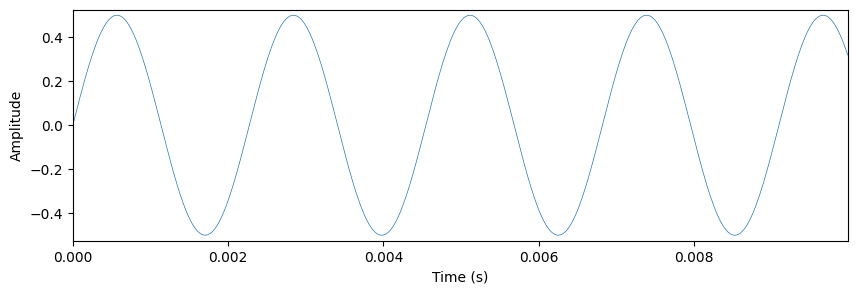

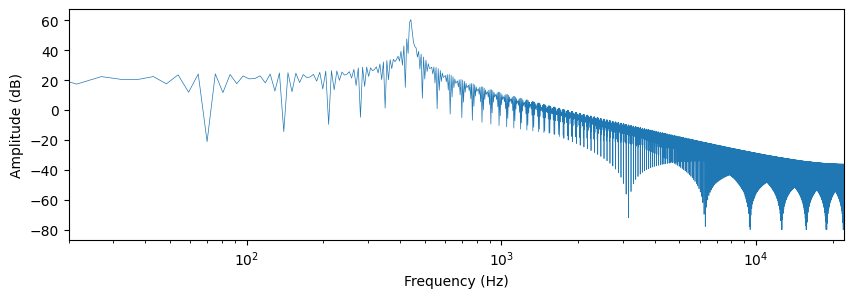

In [3]:
pq.plot(tone, duration=0.01)       # first 10 ms of the waveform
pq.plot_freq(tone, duration=0.1)   # its frequency content

### 2.3 Additive synthesis

Summing harmonics builds a richer timbre. Here a sawtooth-like tone is built from
ten harmonics with amplitudes $A_k = 1/k$.

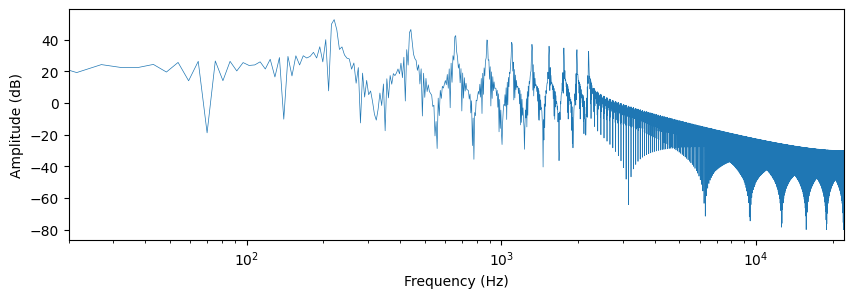

In [4]:
f0 = 220.0
saw = np.zeros_like(t)
for k in range(1, 11):
    saw += (1.0 / k) * np.sin(2 * np.pi * k * f0 * t)

saw_audio = pq.Audio(0.2 * saw, sample_rate=sr)
pq.plot_freq(saw_audio, duration=0.1)
pq.play(saw_audio)

### 2.4 Load and transform audio

Pyquist bundles test audio. `Audio` objects can be sliced (`segment`), resampled
(`resample`), and mixed down (`as_mono`) — each call returns a new `Audio`.

3.00 s at 48000 Hz


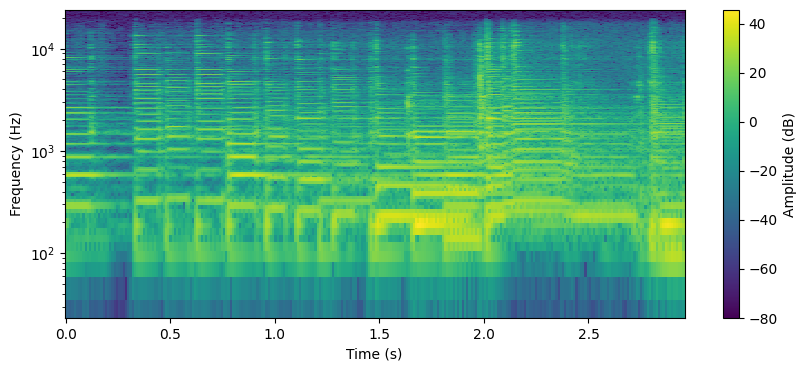

In [5]:
from pyquist.paths import TEST_DATA_DIR

riff = pq.Audio.from_file(
    TEST_DATA_DIR / "388954__fullmetaljedi__blues-riff-in-g-nylon.wav"
)
clip = riff.as_mono().segment(offset=0.0, duration=3.0)
print(f"{clip.duration:.2f} s at {clip.sample_rate} Hz")

pq.plot_spec(clip)
pq.play(clip)

### 2.5 Scores and instruments

A `Score` is a list of `Event`s. An *instrument* is a function from an event to
an `Audio`. `score.render(instrument, metronome=...)` turns the score into sound.

In [6]:
from pyquist.score import Score, Event, BasicMetronome
from pyquist.helper import pitch_to_frequency


def pluck(event):
    dur = event.kwargs["duration"]
    n = int(dur * sr)
    tt = np.arange(n) / sr
    freq = pitch_to_frequency(event.kwargs["pitch"])
    samples = 0.3 * np.sin(2 * np.pi * freq * tt) * np.exp(-4 * tt)
    return pq.Audio(samples, sample_rate=sr)


melody = Score([
    Event(0, {"pitch": 60, "duration": 0.5}),   # C
    Event(1, {"pitch": 64, "duration": 0.5}),   # E
    Event(2, {"pitch": 67, "duration": 0.5}),   # G
    Event(3, {"pitch": 72, "duration": 1.0}),   # C
])

pq.play(melody.render(pluck, metronome=BasicMetronome(120)))

### 2.6 Controlling cell display

Notebook **cell tags** control what appears in the book. Add them to a cell's
metadata (`"tags": [...]`):

| Tag | Effect |
| --- | --- |
| `hide-input` | Collapses the code; output stays visible. |
| `hide-output` | Collapses the output. |
| `remove-input` | Drops the code entirely; shows only output. |
| `remove-cell` | Drops the whole cell from the book. |
| `scroll-output` | Puts long output in a scrolling box. |

The next cell is tagged `hide-input` — you see its plot, but must click to
reveal the code.

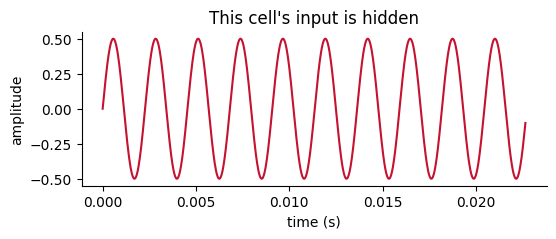

In [7]:
fig, ax = plt.subplots(figsize=(6, 2))
ax.plot(t[:1000], tone.samples[:1000], color="#c41230")
ax.set(xlabel="time (s)", ylabel="amplitude",
       title="This cell's input is hidden")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 3. Glue: weave computed values into prose

The `glue` function (from MyST-NB) captures a value or figure in a code cell so
it can be embedded later in **any markdown cell** — keeping prose and numbers in
sync. The next code cell glues one number and one figure.

In [8]:
from myst_nb import glue

peak_db = 20 * np.log10(saw_audio.peak_amplitude)
glue("peak_db", round(float(peak_db), 1), display=False)

fig, ax = plt.subplots(figsize=(6, 2.4))
ax.magnitude_spectrum(saw_audio.as_mono().samples.ravel(), Fs=sr, scale="dB")
ax.set(xlim=(0, 3000), title="Sawtooth spectrum")
ax.spines[["top", "right"]].set_visible(False)
glue("spectrum_fig", fig, display=False)
plt.close(fig)

A glued value drops straight into a sentence: the sawtooth peaks at
{glue:text}`peak_db` dBFS. A glued figure is placed with the `{glue:figure}`
directive:

```{glue:figure} spectrum_fig
:name: fig-spectrum

A figure computed in a code cell and placed here with `{glue:figure}`.
```

## 4. Using this template

To start a new notebook chapter:

1. Copy `content/template-notebook.ipynb`.
2. Rename it and move it into a `chNN-*/` folder.
3. Register it in `_toc.yml`.
4. Replace these cells with your content.

:::{admonition} Before publishing
:class: warning
Remove this **Notebook Template** page from `_toc.yml` — it is an author
reference, not course content.
:::

:::{note}
Executable pages need Pyquist installed in the build environment and
`execute_notebooks` set to `auto` (or `force`) in `_config.yml`. Both are
already configured in this repository.
:::

:::{seealso}
For prose-only pages that do not need executable code, start from the
{doc}`Markdown Template <template-md>` instead.
:::